In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv('../data/train.csv', sep=',', keep_default_na=False)

In [33]:
df.isnull().sum(axis=0).sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [34]:
df = df.dropna(thresh=len(df)/2, axis=1)
df.isnull().sum(axis=0).sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [35]:
garage_columns = [g for g in df.columns if g.startswith('Garage')]
df[garage_columns].dtypes

GarageType        str
GarageYrBlt       str
GarageFinish      str
GarageCars      int64
GarageArea      int64
GarageQual        str
GarageCond        str
dtype: object

In [36]:
df[garage_columns].isna().sum()

GarageType      0
GarageYrBlt     0
GarageFinish    0
GarageCars      0
GarageArea      0
GarageQual      0
GarageCond      0
dtype: int64

In [37]:
(df['GarageCars'] == 0).sum()

np.int64(81)

In [38]:
(df['GarageArea'] == 0).sum()

np.int64(81)

In [39]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [40]:
garage_str_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']

for col in garage_str_cols:
    df[col] = df[col].fillna('None')
    
df.isna().sum().sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [41]:
fireplace = [f for f in df.columns if f.startswith('Fire')]
df[fireplace].isna().sum()
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [42]:
df[(df['Fireplaces'] == 0) & (df['FireplaceQu'].isna())].shape
df['PoolArea'].iloc[512]

np.int64(0)

In [43]:
df['FireplaceQu'] =  df['FireplaceQu'].fillna('None')
df.isna().sum(axis=0).sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [44]:
df['LotFrontage'] = df.groupby(['Neighborhood'])['LotFrontage'].transform(lambda x: x.fillna(x.median()))
df.isna().sum().sort_values(ascending=False)

TypeError: Cannot perform reduction 'median' with string dtype

In [45]:
bsmt_cols = [b for b in df.columns if b.startswith('Bsmt')]
df[bsmt_cols] = df[bsmt_cols].fillna('None')

df.isna().sum(axis=0).sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [46]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [47]:
electrical_mode = df['Electrical'].mode()[0]
df['Electrical'] = df['Electrical'].fillna(electrical_mode)
df.isna().sum(axis=0).sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

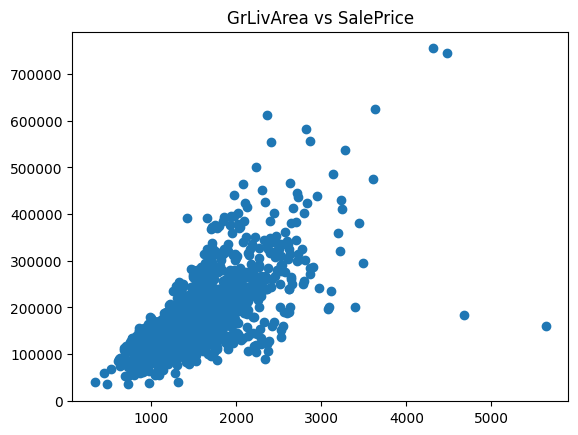

In [ ]:
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.title('GrLivArea vs SalePrice')
plt.show()

outliers count - 0


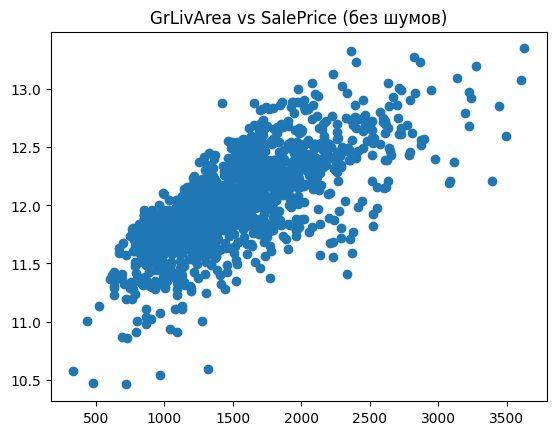

In [ ]:
outliers = df[((df['GrLivArea'] > 4000) & (df['SalePrice'] < 200_000))]
print(f'outliers count - {len(outliers)}')

df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 200_000))]

plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.title('GrLivArea vs SalePrice (без шумов)')
plt.show()

In [ ]:
df.isna().sum(axis=0).sort_values(ascending=False)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [ ]:
df['SalePrice'] = np.log1p(df['SalePrice'])
df['SalePrice']

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64

In [ ]:
df_no_binary = df.copy()

In [ ]:
df_with_binary = df.copy()
df_with_binary['HasGarage'] = (df_with_binary['GarageCars'] > 0).astype(int)
df_with_binary['HasFireplace'] = (df_with_binary['Fireplaces'] > 0).astype(int)
df_with_binary['HasBsmt'] = (df_with_binary['TotalBsmtSF'] > 0).astype(int)
df_with_binary['HasPool'] = (df_with_binary['PoolArea'] > 0 ).astype(int)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

def oneHotEncoding(df):
  object_columns = df.select_dtypes('object').columns

  encoder = OneHotEncoder(sparse_output=False, drop='first')
  encoded = encoder.fit_transform(df[object_columns])
  encoded_cols = encoder.get_feature_names_out(object_columns)

  encoded_df = pd.DataFrame(data=encoded, columns=encoded_cols, index = df.index)

  df_encoded = pd.concat([df, encoded_df], axis=1)
  df_encoded = df_encoded.drop(columns=object_columns)
  
  return df_encoded



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def getResiduals(df): 
  X = df.drop(columns=['SalePrice'])
  Y = df['SalePrice']

  X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42, shuffle=True, test_size=0.2)

  LR_model = LinearRegression()

  LR_model.fit(X_train, Y_train)

  LR_predict = LR_model.predict(X_test)

  residuals = Y_test - LR_predict

  plt.scatter(LR_predict, residuals, alpha=0.5)
  plt.axhline(y=0, color='r')
  plt.xlabel('Predicted log_price')
  plt.ylabel('Residuals')

C:\Users\Татустик\AppData\Local\Temp\ipykernel_11300\996876940.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes('object').columns


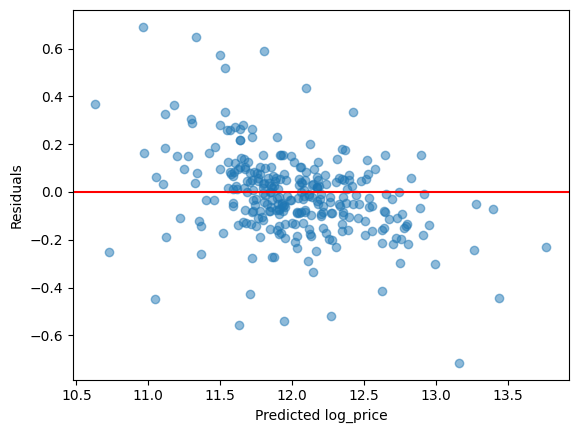

In [ ]:
df_no_binary = oneHotEncoding(df_no_binary)
getResiduals(df_no_binary)

C:\Users\Татустик\AppData\Local\Temp\ipykernel_11300\996876940.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes('object').columns


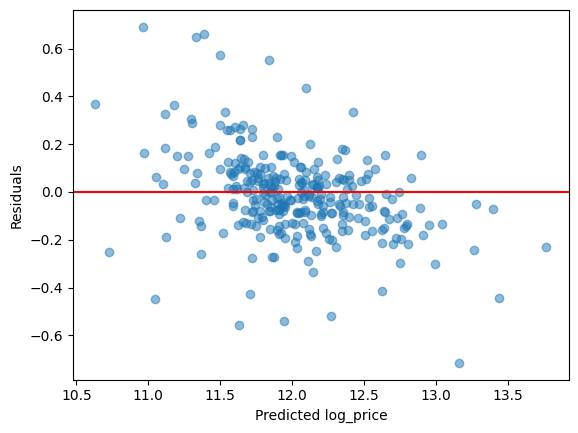

In [ ]:
df_with_binary = oneHotEncoding(df_with_binary)
getResiduals(df_with_binary)